In [1]:
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_from_disk
from tqdm.notebook import tqdm

In [2]:
# flatten cosine scores
def extract_cosine_scores(dataset):
    all_scores = []
    for example in tqdm(dataset):
        all_scores.extend(example["cosine_scores"])
    return np.array(all_scores)

In [4]:
def create_distribution(mining_type):
    train_dataset = load_from_disk(f"outputs/clap/datasets/train-function-pool-{mining_type}")
    valid_dataset = load_from_disk(f"outputs/clap/datasets/valid-function-pool-{mining_type}")

    train_scores = extract_cosine_scores(train_dataset)
    valid_scores = extract_cosine_scores(valid_dataset)

    plt.figure(figsize=(8, 5))
    plt.hist(train_scores, bins=50, alpha=0.5, label='Train', color='blue', density=True)
    plt.hist(valid_scores, bins=50, alpha=0.5, label='Validation', color='orange', density=True)
    plt.title(f"Cosine Score Distribution with {mining_type}")
    plt.xlabel("Cosine Similarity Score")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

  0%|          | 0/2716481 [00:00<?, ?it/s]

  0%|          | 0/2475051 [00:00<?, ?it/s]

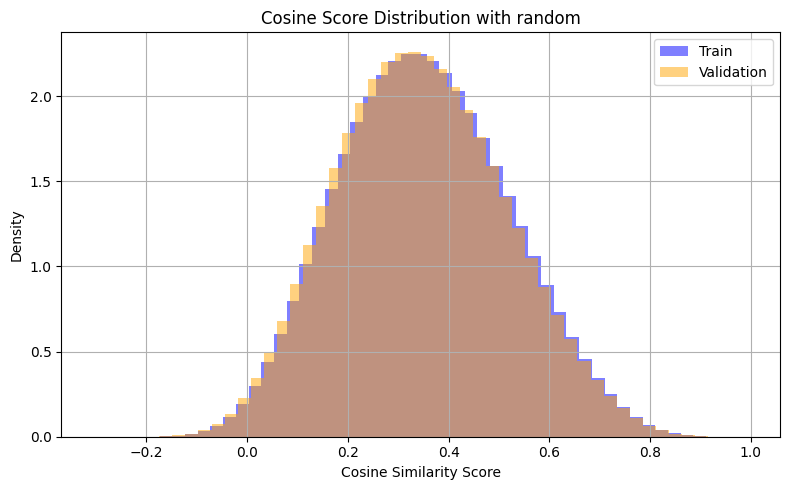

In [5]:
create_distribution('random')

  0%|          | 0/2716481 [00:00<?, ?it/s]

  0%|          | 0/2475051 [00:00<?, ?it/s]

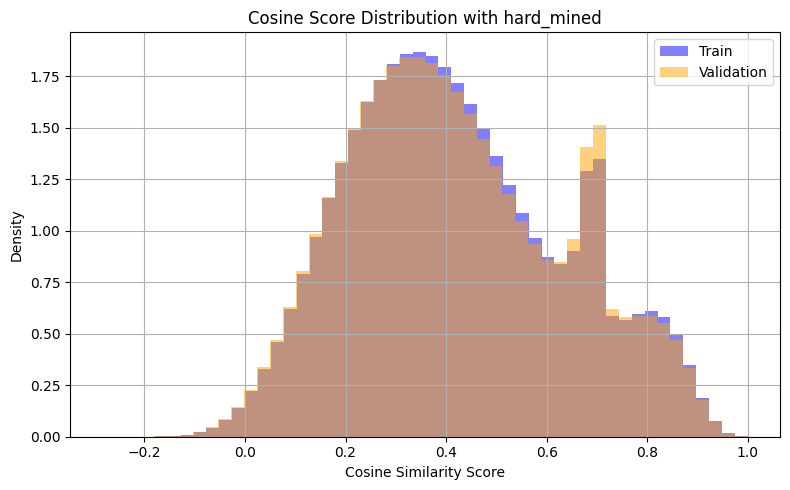

In [6]:
create_distribution('hard_mined')